<a href="https://colab.research.google.com/github/AhmadMuhaiminKamil/AhmadMuhaiminKamil/blob/main/Praktikum5/dimensionalityReductionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
iris = load_iris()
x = iris['data']
y = iris['target']

n_samples, n_features = x.shape

print('Number of sample',n_samples)
print('Number of features',n_features)

Number of sample 150
Number of features 4


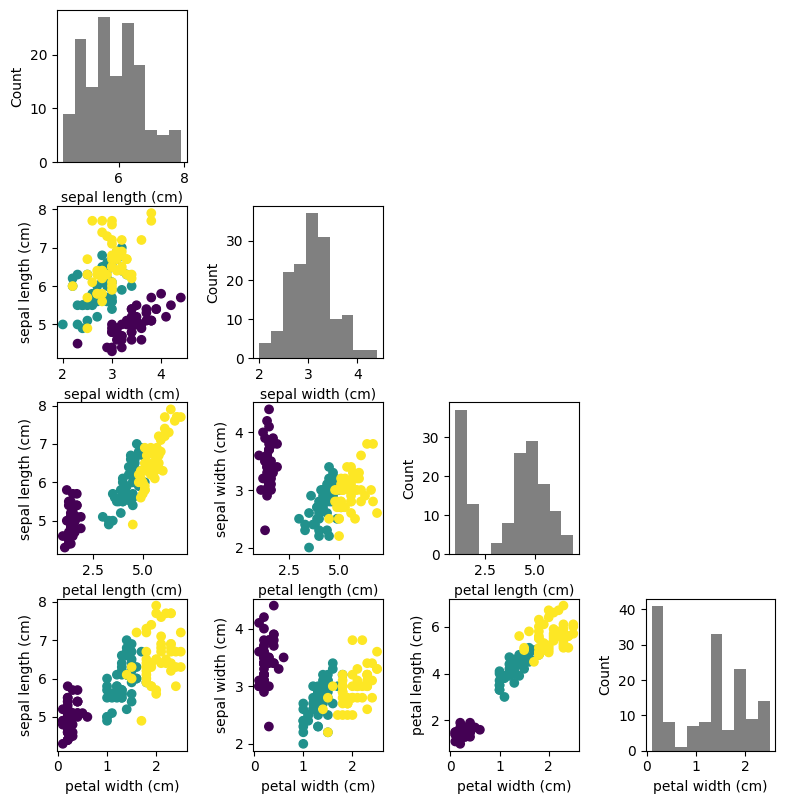

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=n_features, ncols=n_features, figsize= (8,8))
fig.tight_layout()

names = iris.feature_names

for i, j in zip(*np.triu_indices_from(ax, k=1)):
    ax[j, i].scatter(x[:, j], x[:, i], c=y)
    ax[j, i].set_xlabel(names[j])
    ax[j, i].set_ylabel(names[i])
    ax[i, j].set_axis_off()

for i in range (n_features):
  ax[i, i].hist(x[:, i], color = 'grey')
  ax[i, i].set_ylabel('Count')
  ax[i, i].set_xlabel(names[i])

plt.show()

In [3]:
def mean(x):
    return sum(x)/len(x)

def std(x):
    return (sum((i-mean(x))**2 for i in x)/len(x))**0.5

def standarize_data(x):
    return (x-mean(x))/std(x)

x_std = standarize_data(x)

In [4]:
print(x)
print(x_std)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [5]:
def covariance(x):
    return(x.T @ x) / (x.shape[0]-1)

cov_mat = covariance(x_std)

cov_mat

array([[ 1.00671141, -0.11835884,  0.87760447,  0.82343066],
       [-0.11835884,  1.00671141, -0.43131554, -0.36858315],
       [ 0.87760447, -0.43131554,  1.00671141,  0.96932762],
       [ 0.82343066, -0.36858315,  0.96932762,  1.00671141]])

In [6]:
from numpy.linalg import eig

#eigendecomposition of covariance matrix
eig_vals, eig_vecs = eig (cov_mat)

#adjusting the eigenvectors (loadings) that are largest in absolute value to be positive
max_abs_idx = np.argmax(np.abs(eig_vecs), axis=0)
signs = np.sign(eig_vecs[max_abs_idx, range(eig_vecs.shape[0])])
eig_vecs = eig_vecs*signs[np.newaxis,:]
eig_vecs = eig_vecs.T

print ('Eigenvalues \n', eig_vals)
print ('Eigenvectors \n',eig_vecs)

Eigenvalues 
 [2.93808505 0.9201649  0.14774182 0.02085386]
Eigenvectors 
 [[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]
 [ 0.71956635 -0.24438178 -0.14212637 -0.63427274]
 [-0.26128628  0.12350962  0.80144925 -0.52359713]]


In [7]:
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]

eig_pairs.sort(key=lambda x: x[0], reverse=True)

eig_vals_sorted = np.array([x[0] for x in eig_pairs])
eig_vecs_sorted = np.array([x[1] for x in eig_pairs])

print(eig_pairs)

[(np.float64(2.9380850501999918), array([ 0.52106591,  0.37741762,  0.71956635, -0.26128628])), (np.float64(0.920164904162487), array([-0.26934744,  0.92329566, -0.24438178,  0.12350962])), (np.float64(0.14774182104494785), array([ 0.5804131 ,  0.02449161, -0.14212637,  0.80144925])), (np.float64(0.020853862176462023), array([ 0.56485654,  0.06694199, -0.63427274, -0.52359713]))]


In [8]:
k = 2
w = eig_vecs_sorted[:k, :]

print(w.shape)

(2, 4)


Explained variance: [72.96 22.85  3.67  0.52]
Cumulative explained variance: [ 72.96  95.81  99.48 100.  ]


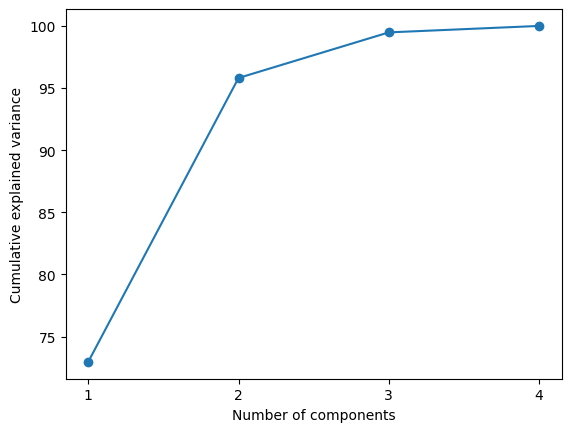

In [9]:
eig_vals_total = sum(eig_vals)
explained_variance = [(i / eig_vals_total)*100 for i in eig_vals_sorted]
explained_variance = np.round(explained_variance, 2)
cum_explained_variance = np.cumsum(explained_variance)

print('Explained variance: {}'.format(explained_variance))
print('Cumulative explained variance: {}'.format(cum_explained_variance))

plt.plot(np.arange(1,n_features+1), cum_explained_variance, '-o')
plt.xticks(np.arange(1,n_features+1))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [10]:
x_proj = x_std.dot(w.T)
print(x_proj.shape)
print(x.shape)

(150, 2)
(150, 4)


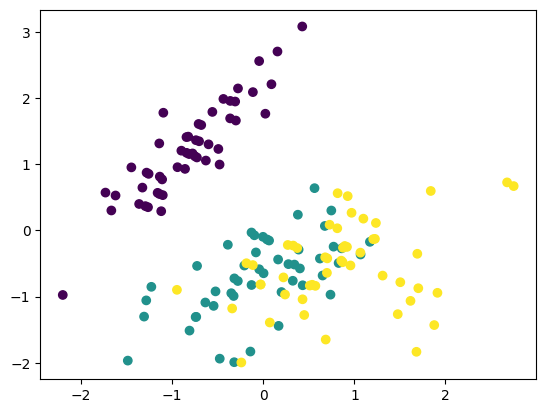

In [11]:
plt.scatter(x_proj[:,0],x_proj[:,1],c=y)


**Menggunakan PCA**

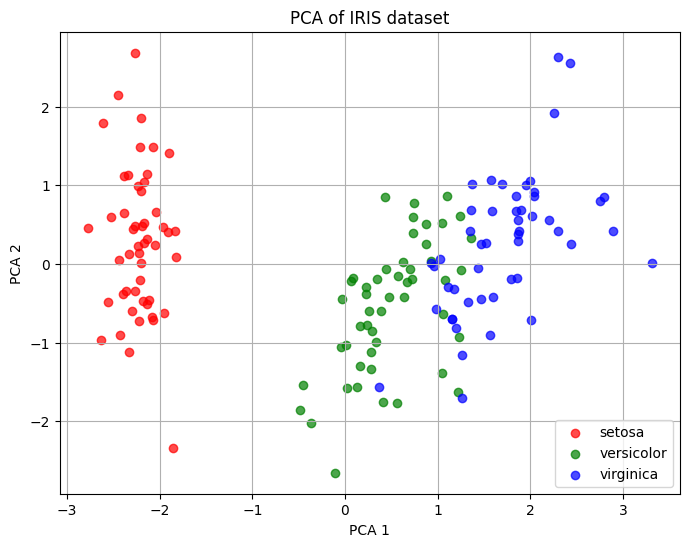

In [12]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
x = iris['data']
y = iris['target']
target_names = iris['target_names']

# Standarisasi
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# PCA reduksi ke 2 dimensi
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# Visualisasi
plt.figure(figsize=(8,6))
colors = ['r', 'g', 'b']
for i, target_name in enumerate(target_names):
    plt.scatter(x_pca[y == i, 0], x_pca[y == i, 1], alpha=0.7, label=target_name, color=colors[i])
plt.legend()
plt.title('PCA of IRIS dataset')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()


In [13]:
print("Rasio variansi:", pca.explained_variance_ratio_)
print("Total variansi yang dijelaskan:", sum(pca.explained_variance_ratio_))
print("Data setelah PCA (2 dimensi):\n", x_pca[:5])  # tampilkan 5 data pertama


Rasio variansi: [0.72962445 0.22850762]
Total variansi yang dijelaskan: 0.9581320720000166
Data setelah PCA (2 dimensi):
 [[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]
